In [30]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver   # Persistence

In [31]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[ list[BaseMessage], add_messages ]


In [32]:
llm = ChatOpenAI()
def chat_node(my_state:ChatState):
    # take user query from state
    messages = my_state["messages"]

    # send to llm
    response= llm.invoke(messages)

    # response store state
    return {"messages": [response]}

In [33]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

program_ram = MemorySaver()   
chatbot = graph.compile(checkpointer=program_ram)

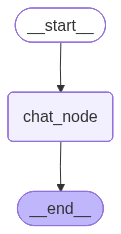

In [34]:
chatbot

In [35]:
initial_state = {
    "messages": [HumanMessage(content=("What is capital of India?"))]
}

chatbot.invoke(initial_state)["messages"][-1]

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
thread_id = 1

while True:
    user_message = input('Type here: ')

    print('User: ', user_message)

    if user_message.strip() in ["Exit", "quit", 'bye']:
        break

    config = {"configuration": {"thread_id": thread_id}}

    response = chatbot.invoke({"messages": [HumanMessage(content=user_message)]}, config=config)

    print('AI: ', response["messages"][-1].content)
    



User:  


ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id